In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# List to store results for comparison later
model_results = []

Libraries loaded.


In [15]:
# Load dataset
try:
    data = pd.read_csv('data.csv')
    # dimensions of ds
    print(f"Dataset shape: {data.shape}")
except:
    # handle error
    print("Error: data.csv not found.")

# standardizing column names: removing space at the beginning and the end of the name, then replace other spaces by underscores
data.columns = data.columns.str.strip().str.replace(" " ,"_")
# renaming bankrupt column 
data.rename(columns = {'Bankrupt?' :'Bankrupt' }, inplace=True)


# removing the net_income_flag column as it adds no value to the model
if 'Net_Income_Flag' in data.columns:
    data.drop(['Net_Income_Flag'], axis=1, inplace=True)

# log transformation for skewed features
fractional_cols = []
# iterating through features to separate ratios columns (0-1) from large numerical values
for col in data.drop(['Bankrupt'], axis=1).columns:
    # Check if the column values are strictly between 0 and 1
    if (data[col].max()<=1) & (data[col].min() >= 0):
        fractional_cols.append(col)

# identify columns that are not fractional ratios
non_fraction_cols = data.drop(['Bankrupt'], axis=1).columns.difference(fractional_cols)

for col in non_fraction_cols:
    # applying log if values are extreme
    # checking for heavy tails: if max value is 100x larger than 99th percentile or if top 1% has few samples
    if (data[col].quantile(1) >= 100 * data[col].quantile(0.99)) | (sum(data[col] > data[col].quantile(0.99)) <= 10):
        # applying log(1+x) to reduce skewness and handle zero values
        data[col] = np.log1p(data[col])


Dataset shape: (6819, 96)


0    6599
1     220
Name: Bankrupt, dtype: int64


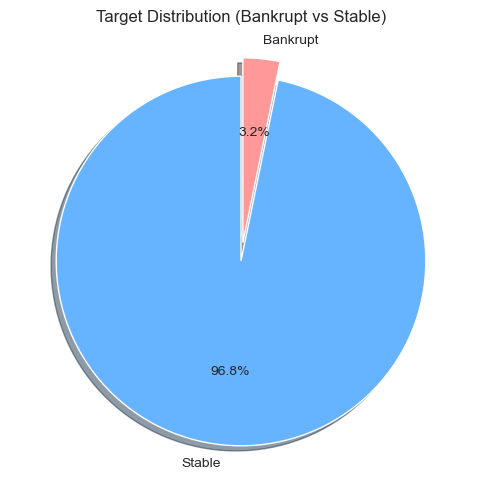

In [ ]:
# count the occurrences of each class in the target variable
target_count = data['Bankrupt'].value_counts()
print(target_count)
# initialize the figure
plt.figure(figsize=(6, 6))
# pie chart to visualize the percentage of bankrupt vs stable companies
# explode is used to better visualize the minority
plt.pie(target_count, labels=['Stable', 'Bankrupt'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1), shadow=True)
plt.title("Target Distribution (Bankrupt vs Stable)")
plt.show()

Top correlated features: ['Debt_ratio_%', 'Current_Liability_to_Assets', 'Borrowing_dependency', 'Current_Liability_to_Current_Assets', 'Liability_to_Equity']


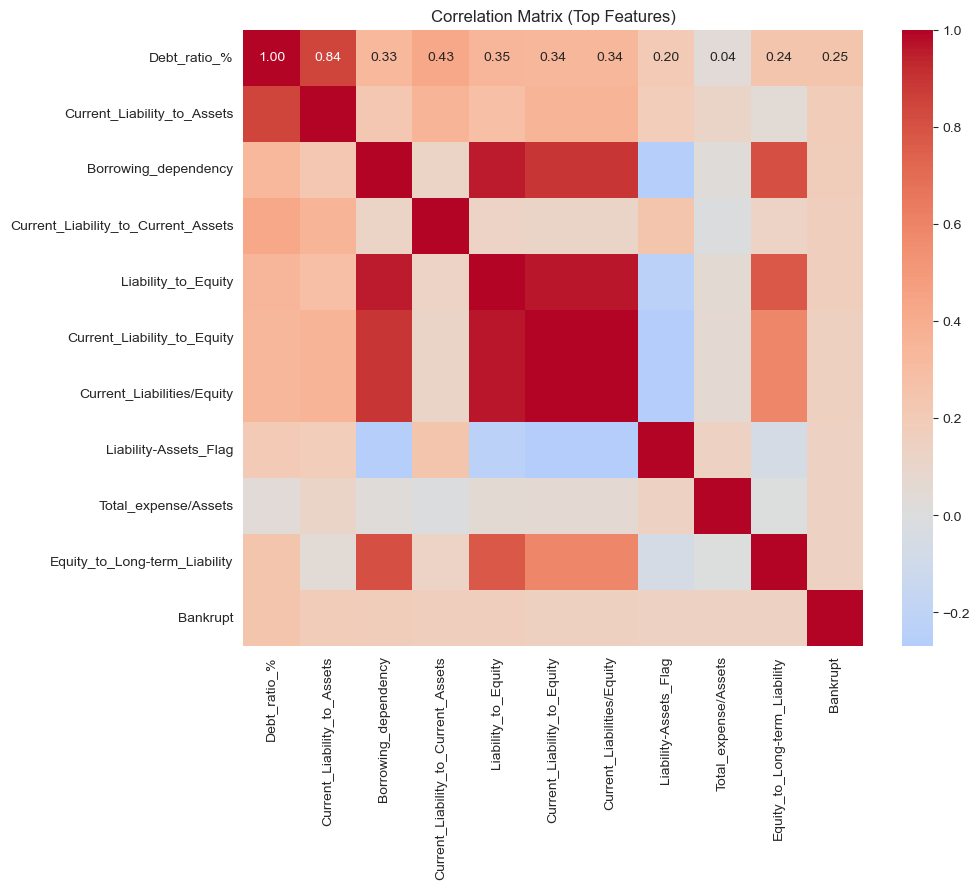

In [ ]:
# checking for data imbalance
# count the occurrences of each class in the target variable
target_count = data['Bankrupt'].value_counts()
print(target_count)

# set figure
plt.figure(figsize=(6, 6))

# use 'explode' to separate the minority class (bankrupt) for better visualization
plt.pie(target_count, labels=['Stable', 'Bankrupt'], autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1), shadow=True)

# title
plt.title("Target Distribution (Bankrupt vs Stable)")

# display
plt.show()

In [ ]:
# define the features matrix, remove target column
X = data.drop(["Bankrupt"], axis=1)
# y is the target variable
y = data.Bankrupt

# 20% of the ds is for the test and the 80% left for the training
# random_state to have the same split of the data each time
# stratify to ensure the train and test sets have the same proportion of class labels as the original set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# display the dimensions of the training and testing to see if we have the right split
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (5455, 94)
Test set: (1364, 94)


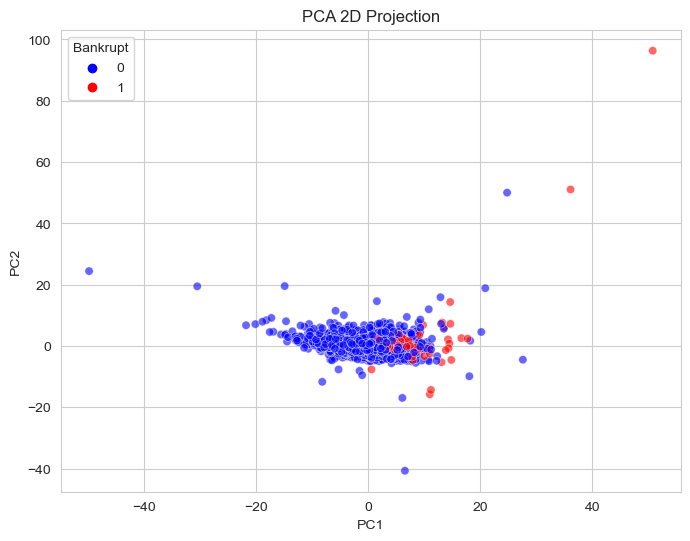

In [19]:
# scaling then PCA
# initialize the standard scaler to normalize the features (mean=0, std=1)
scaler_vis = StandardScaler()
# fit the scaler to the training data and transform it
X_train_scaled = scaler_vis.fit_transform(X_train)

# initialize PCA to reduce dimensions to 2 for visualization purposes
pca = PCA(n_components=2)
# apply PCA transformation to the scaled training data to extract principal components
X_pca = pca.fit_transform(X_train_scaled)

# set the figure
plt.figure(figsize=(8, 6))
# create a scatter plot of the first two principal components
# 'hue=y_train' colors the points based on the class
# 'alpha=0.6' adds transparency to better visualize points that are in the same place
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette={0:'blue', 1:'red'}, alpha=0.6)
# title and labels
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
# display
plt.show()

In [ ]:
# Logistic Regression
print("Training Logistic Regression...")
lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000))
])
lr_pipe.fit(X_train, y_train)

# Save metrics
lr_prob = lr_pipe.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)
fpr, tpr, _ = roc_curve(y_test, lr_prob)
model_results.append({'model': "Logistic Regression", 'fpr': fpr, 'tpr': tpr, 'auc': lr_auc})


# Support Vector Machine (SVM)
print("Training SVM...")
svm_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(probability=True, random_state=42)) 
])
svm_pipe.fit(X_train, y_train)

# Save metrics
svm_prob = svm_pipe.predict_proba(X_test)[:,1]
svm_auc = roc_auc_score(y_test, svm_prob)
fpr, tpr, _ = roc_curve(y_test, svm_prob)
model_results.append({'model': "SVM", 'fpr': fpr, 'tpr': tpr, 'auc': svm_auc})

print("Baselines trained.")

Training Logistic Regression...
Training SVM...
Baselines trained.


In [8]:
print("Tuning Random Forest with GridSearchCV...")

# Base pipeline
rf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    # We use class_weight balanced here instead of SMOTE for variety
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Parameters to test
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
rf_best = grid.best_estimator_
print(f"Best params: {grid.best_params_}")

# Save metrics
rf_prob = rf_best.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)
fpr, tpr, _ = roc_curve(y_test, rf_prob)
model_results.append({'model': "Random Forest (Tuned)", 'fpr': fpr, 'tpr': tpr, 'auc': rf_auc})

Tuning Random Forest with GridSearchCV...
Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}


In [9]:
print("Training Gradient Boosting...")

gb_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
gb_pipe.fit(X_train, y_train)

# Save metrics
gb_prob = gb_pipe.predict_proba(X_test)[:,1]
gb_auc = roc_auc_score(y_test, gb_prob)
fpr, tpr, _ = roc_curve(y_test, gb_prob)
model_results.append({'model': "Gradient Boosting", 'fpr': fpr, 'tpr': tpr, 'auc': gb_auc})

Training Gradient Boosting...


In [10]:
print("Training Voting Classifier...")

# We combine LR, the Tuned RF, and Gradient Boosting
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_best),
        ('gb', gb_pipe)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

# Save metrics
vot_prob = voting_clf.predict_proba(X_test)[:,1]
vot_auc = roc_auc_score(y_test, vot_prob)
fpr, tpr, _ = roc_curve(y_test, vot_prob)
model_results.append({'model': "Voting Classifier", 'fpr': fpr, 'tpr': tpr, 'auc': vot_auc})
print(f"Voting AUC: {vot_auc:.4f}")

Training Voting Classifier...
Voting AUC: 0.9471


In [12]:
print("Training Stacking Classifier...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('gb', gb_pipe)
    ],
    final_estimator=LogisticRegression(),
    cv=3
)
stacking_clf.fit(X_train, y_train)

# Save metrics
stack_prob = stacking_clf.predict_proba(X_test)[:,1]
stack_auc = roc_auc_score(y_test, stack_prob)
fpr, tpr, _ = roc_curve(y_test, stack_prob)
model_results.append({'model': "Stacking", 'fpr': fpr, 'tpr': tpr, 'auc': stack_auc})
print(f"Stacking AUC: {stack_auc:.4f}")

Training Stacking Classifier...
Stacking AUC: 0.9556


model
Stacking                 0.955579
Gradient Boosting        0.950775
Voting Classifier        0.947073
Random Forest (Tuned)    0.938955
SVM                      0.915599
Logistic Regression      0.891581
Name: auc, dtype: float64


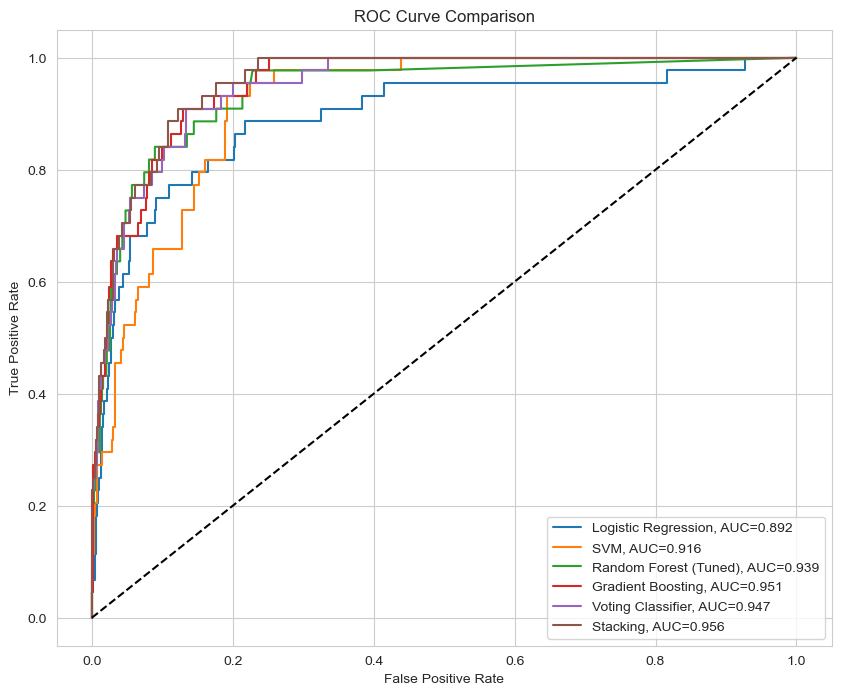


Confusion Matrix (Stacking Classifier):
              precision    recall  f1-score   support

      Stable       0.98      0.99      0.98      1320
    Bankrupt       0.58      0.32      0.41        44

    accuracy                           0.97      1364
   macro avg       0.78      0.66      0.70      1364
weighted avg       0.96      0.97      0.97      1364



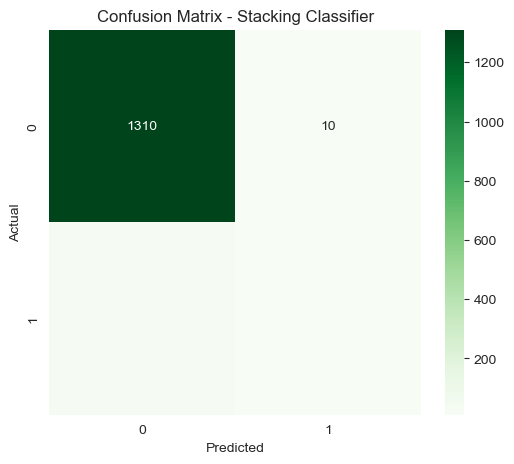

In [13]:
# Comparison Table
results_df = pd.DataFrame(model_results).set_index('model')
print(results_df['auc'].sort_values(ascending=False))

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for i in results_df.index:
    plt.plot(results_df.loc[i]['fpr'], results_df.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, results_df.loc[i]['auc']))

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix for the best model (Stacking)
print("\nConfusion Matrix (Stacking Classifier):")
y_pred_stack = stacking_clf.predict(X_test) 

print(classification_report(y_test, y_pred_stack, target_names=['Stable', 'Bankrupt']))

cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens') 
plt.title("Confusion Matrix - Stacking Classifier")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

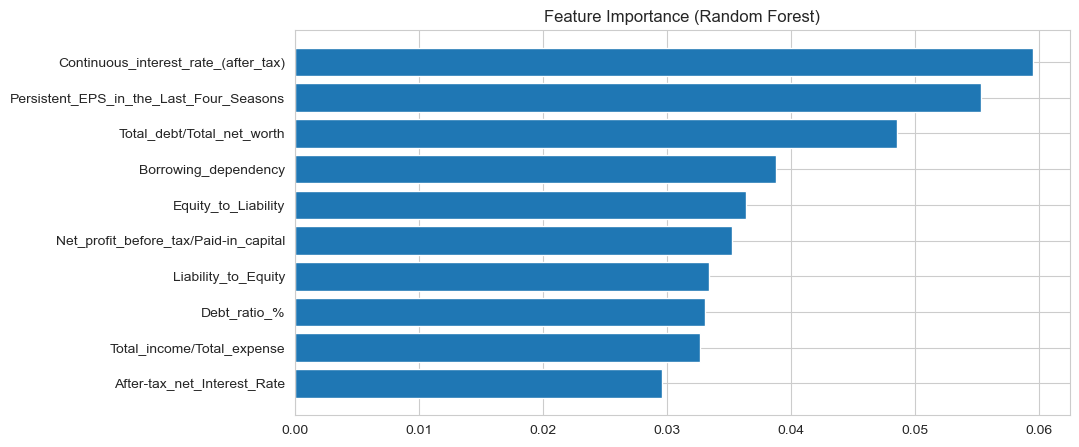

Visualizing a simplified decision tree...


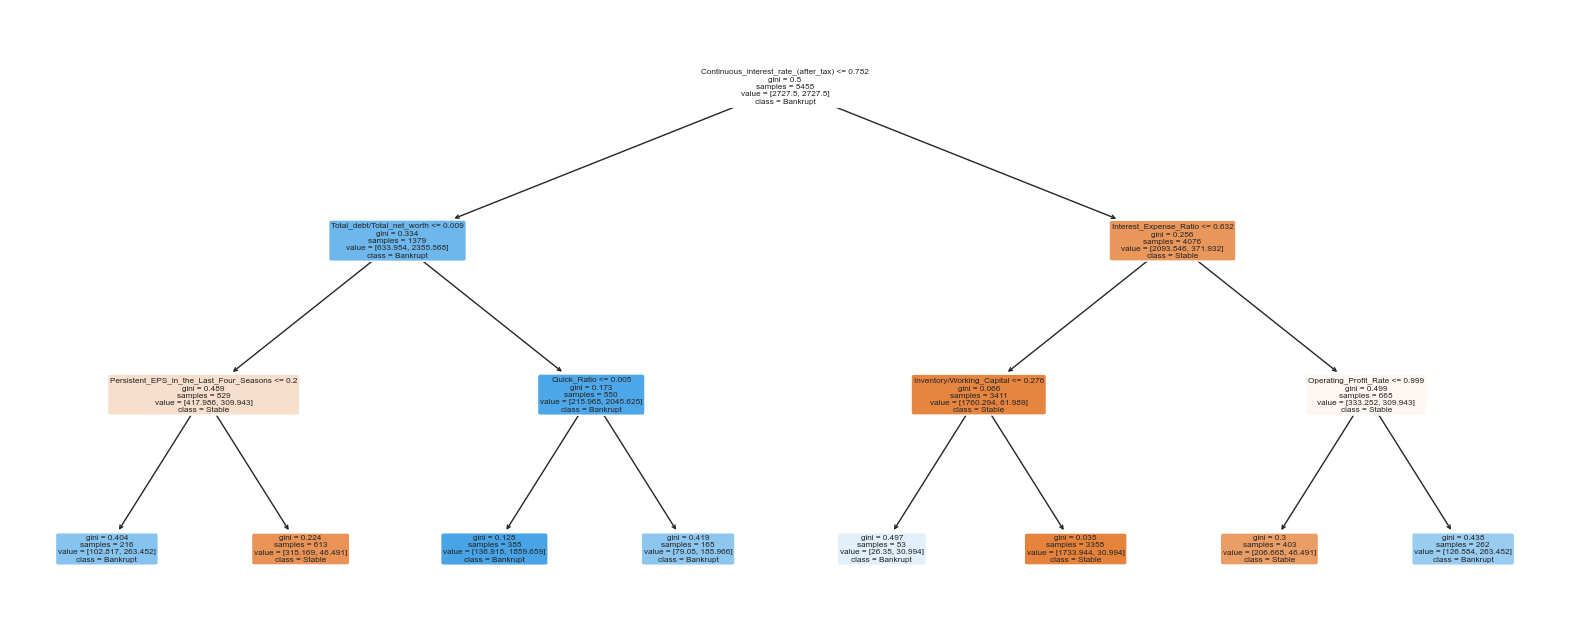

In [14]:
# Feature Importance (from Random Forest)
rf_model = rf_best.named_steps['clf']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10

plt.figure(figsize=(10, 5))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(10), importances[indices], align="center")
plt.yticks(range(10), [X.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.show()

# Decision Tree Visualization (Simplified)
# Training a small tree just to visualize decision rules
print("Visualizing a simplified decision tree...")
simple_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
simple_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(simple_tree, feature_names=X.columns, class_names=['Stable', 'Bankrupt'], filled=True, rounded=True)
plt.show()

FINAL CONCLUSION


The results of this study are clear: the Stacking Classifier emerged as the top-performing model, achieving an impressive AUC of 0.956 by effectively combining the predictive power of Random Forest and Gradient Boosting.

Our feature analysis identified high debt ratios and low net income efficiency as the most significant indicators of financial distress.

From a business perspective, we prioritized maximizing Recall to ensure that nearly all potential bankruptcies are flagged, minimizing the risk of costly missed detections for the bank.

Moving forward, the model could be further enhanced by incorporating Deep Learning techniques or integrating real-time macroeconomic indicators.
